In [4]:
!pip install pandas openpyxl xlrd

In [5]:
import pandas as pd 

In [6]:
data = pd.read_excel("C:/Users/mocim/OneDrive/Desktop/Lessons/Week 2/Project/raw_data_shark_attacks.xls")

In [7]:
df = data[["Country", "Activity", "Location", "Sex", "Fatal Y/N", "Species ", "Type"]]

In [8]:
df.columns = df.columns.str.strip()

In [9]:
df.shape

(7097, 7)

In [10]:
df.tail()

,Country,Activity,Location,Sex,Fatal Y/N,Species,Type
7092,AUSTRALIA,Diving,Roebuck Bay,M,Y,NaN,Unprovoked
7093,AUSTRALIA,Pearl diving,NaN,M,Y,NaN,Unprovoked
7094,USA,Swimming,Ocracoke Inlet,M,Y,NaN,Unprovoked
7095,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",M,Y,NaN,Unprovoked
7096,CEYLON (SRI LANKA),Swimming,"Below the English fort, Trincomalee",M,Y,NaN,Unprovoked


### MOCI

In [11]:
df.isna().sum()/len(df) *100

Country       0.704523
Activity      8.214739
Location      7.989291
Sex           8.144286
Fatal Y/N     7.904748
Species      44.117233
Type          0.253628
dtype: float64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7097 entries, 0 to 7096
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Country    7047 non-null   object
 1   Activity   6514 non-null   object
 2   Location   6530 non-null   object
 3   Sex        6519 non-null   object
 4   Fatal Y/N  6536 non-null   object
 5   Species    3966 non-null   object
 6   Type       7079 non-null   object
dtypes: object(7)
memory usage: 388.2+ KB


- Replace null values for Unknown for Activity, Sex and Fatal Y/N as they are around 8%

In [13]:
df[["Activity", "Sex", "Fatal Y/N"]] = df[["Activity", "Sex", "Fatal Y/N"]].fillna("Unknown")

C:\Users\mocim\AppData\Local\Temp\ipykernel_20844\3811356152.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[["Activity", "Sex", "Fatal Y/N"]] = df[["Activity", "Sex", "Fatal Y/N"]].fillna("Unknown")


- Check duplicates

In [14]:
data.duplicated().sum()

np.int64(0)

In [15]:
df.duplicated().sum()

np.int64(325)

In [16]:
df["Sex"].value_counts()

Sex
M          5689
F           812
Unknown     578
M             6
?             2
F             2
N             2
M F           1
 M            1
m             1
lli           1
M x 2         1
.             1
Name: count, dtype: int64

- Check inconsistent values

In [17]:
df ["Sex"] = df ["Sex"].str.strip()

C:\Users\mocim\AppData\Local\Temp\ipykernel_20844\3234921729.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df ["Sex"] = df ["Sex"].str.strip()


In [18]:
df ["Sex"] = df ["Sex"].str.upper()

C:\Users\mocim\AppData\Local\Temp\ipykernel_20844\3511102203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df ["Sex"] = df ["Sex"].str.upper()


In [19]:
df ["Sex"] = df ["Sex"].replace (["?", "UNKNOWN", "N", "M F", "LLI", ".", "M X 2"], "Unknown")

C:\Users\mocim\AppData\Local\Temp\ipykernel_20844\2089057638.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df ["Sex"] = df ["Sex"].replace (["?", "UNKNOWN", "N", "M F", "LLI", ".", "M X 2"], "Unknown")


In [20]:
df["Activity"].nunique()

1614

In [21]:
df["Activity"].value_counts().head(30)

Activity
Surfing            1153
Swimming           1018
Unknown             586
Fishing             494
Spearfishing        393
Wading              178
Bathing             164
Diving              151
Snorkeling          135
Standing            113
Scuba diving         84
Body boarding        63
Body surfing         50
Swimming             47
Boogie boarding      42
Kayaking             41
Free diving          33
Treading water       33
Fell overboard       32
Pearl diving         32
Windsurfing          20
Boogie Boarding      18
Walking              17
Fishing              16
Floating             16
Canoeing             16
Shark fishing        15
Surf fishing         14
Surf-skiing          13
Scuba Diving         13
Name: count, dtype: int64

In [22]:
df["Activity"].value_counts().info()

<class 'pandas.core.series.Series'>
Index: 1614 entries, Surfing to Wreck of  large double sailing canoe
Series name: count
Non-Null Count  Dtype
--------------  -----
1614 non-null   int64
dtypes: int64(1)
memory usage: 25.2+ KB


In [23]:
df["Activity"] = df["Activity"].str.strip().str.lower()

C:\Users\mocim\AppData\Local\Temp\ipykernel_20844\3029557794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Activity"] = df["Activity"].str.strip().str.lower()


In [24]:
df["Activity"].isna().sum()

np.int64(0)

In [25]:
df.loc[df["Activity"].str.contains("surf|Boarding|boarding"), "Activity"] = "Surfing related"
df.loc[df["Activity"].str.contains("fishing"), "Activity"] = "Fishing related"
df.loc[df["Activity"].str.contains("swim"), "Activity"] = "Swimming related"
df.loc[df["Activity"].str.contains("diving"), "Activity"] = "Diving related"
df.loc[df["Activity"] == "Boarding related", "Activity"] = "Surfing related"
df.loc[df["Activity"].str.contains ("walking|playing"), "Activity"] = "Non water activities"

df.loc [df["Activity"] == "Non water activities", "Activity"] = "Other"  # Changed my mind, want them 2 in Others 
df.loc [df["Activity"] == "sea disaster", "Activity"] = "Other"

In [26]:
df.loc [ df["Activity"].str.contains ("kayaking|canoeing|rowing|maybe fell overboard|fell overboard"), "Activity" ] = "Boating related"

In [27]:
df.loc[ df["Activity"].isin(["wading", "bathing", "standing", "treading water", "floating"]), "Activity"] = "Swimming related"
df.loc [ df["Activity"].isin( ["snorkeling"]), "Activity" ] = "Diving related" 

In [28]:
activity_counts = df["Activity"].value_counts()

rare_activities = activity_counts [activity_counts < 10].index
df.loc[df["Activity"].isin(rare_activities), "Activity"] = "Other"

In [29]:
df["Activity"].value_counts().head(20)

Activity
Swimming related    1766
Surfing related     1652
Fishing related     1272
Other                977
Diving related       702
unknown              586
Boating related      142
Name: count, dtype: int64

In [30]:
df["Fatal Y/N"].isna().sum()

np.int64(0)

In [31]:
df["Fatal Y/N"].value_counts()

Fatal Y/N
N          4950
Y          1494
Unknown     561
UNKNOWN      71
 N            7
F             5
M             3
n             1
Nq            1
2017          1
Y x 2         1
N             1
y             1
Name: count, dtype: int64

In [32]:
df["Fatal Y/N"] = df["Fatal Y/N"].str.upper().str.strip()

C:\Users\mocim\AppData\Local\Temp\ipykernel_20844\3861697453.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Fatal Y/N"] = df["Fatal Y/N"].str.upper().str.strip()


In [33]:
df["Fatal Y/N"] = df["Fatal Y/N"].replace({"N": "No","Y": "Yes", "UNKNOWN": "Unknown"})

C:\Users\mocim\AppData\Local\Temp\ipykernel_20844\2764064334.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Fatal Y/N"] = df["Fatal Y/N"].replace({"N": "No","Y": "Yes", "UNKNOWN": "Unknown"})


In [34]:
df["Fatal Y/N"].isna().sum()

np.int64(1)

In [35]:
df["Fatal Y/N"] = df["Fatal Y/N"].fillna ("Unknown")

C:\Users\mocim\AppData\Local\Temp\ipykernel_20844\2170484850.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Fatal Y/N"] = df["Fatal Y/N"].fillna ("Unknown")


In [36]:
df.loc[ df["Fatal Y/N"].str.contains("F|M|NQ|Y X 2"), "Fatal Y/N"] = "Unknown"

In [37]:
df

,Country,Activity,Location,Sex,Fatal Y/N,Species,Type
0,Australia,Fishing related,Michaelmas Island King George Sound,M,Yes,Great White shark 4.5 m,Unprovoked
1,Brazil,Swimming related,Boa Via gem beach,F,No,Tiger shark 3m,Unprovoked
2,Brazil,Swimming related,PierrebBeach,M,No,Bull shark,Unprovoked
3,Australia,Surfing related,Red Cliff beach Yuraygir National Park,M,No,Bull shark,Unprovoked
4,USA,Surfing related,Cromwell's beach Oahu,M,No,2.4m (8ft) shark,Unprovoked
...,...,...,...,...,...,...,...
7092,AUSTRALIA,Diving related,Roebuck Bay,M,Yes,NaN,Unprovoked
7093,AUSTRALIA,Diving related,NaN,M,Yes,NaN,Unprovoked
7094,USA,Swimming related,Ocracoke Inlet,M,Yes,NaN,Unprovoked
7095,PANAMA,unknown,"Panama Bay 8ºN, 79ºW",M,Yes,NaN,Unprovoked


In [38]:
df.to_csv("shark_clean.csv", index=False)  #copy 

### Hypothesis

In [39]:
df.groupby("Activity")["Fatal Y/N"].value_counts()

Activity          Fatal Y/N
Boating related   No             84
                  Yes            49
                  Unknown         9
Diving related    No            485
                  Yes           147
                  Unknown        70
Fishing related   No           1010
                  Yes           181
                  Unknown        81
Other             No            528
                  Yes           343
                  Unknown       106
Surfing related   No           1470
                  Yes           120
                  Unknown        62
Swimming related  No           1071
                  Yes           546
                  Unknown       149
unknown           No            311
                  Unknown       166
                  Yes           109
Name: count, dtype: int64

In [40]:
pd.crosstab(df["Activity"], df["Fatal Y/N"])

df_fatal = df[df["Fatal Y/N"] != "Unknown"]  # Exclude Unknown from rows. But here does nothing because the row is "unknown" lowercase. 


In [41]:
df_fatal["Fatal Y/N"].value_counts()

Fatal Y/N
No     4959
Yes    1495
Name: count, dtype: int64

In [42]:
fatal_rate = (pd.crosstab(df_fatal["Activity"], df_fatal["Fatal Y/N"], normalize="index") * 100).round (2)

fatal_rate

Fatal Y/N,No,Yes
Activity,,
Boating related,63.16,36.84
Diving related,76.74,23.26
Fishing related,84.80,15.20
Other,60.62,39.38
Surfing related,92.45,7.55
Swimming related,66.23,33.77
unknown,74.05,25.95


In [43]:
df_fatal = fatal_rate.drop ("unknown")  # Remove unknown rows 

In [44]:
fatal_rate.index

Index(['Boating related', 'Diving related', 'Fishing related', 'Other',
       'Surfing related', 'Swimming related', 'unknown'],
      dtype='object', name='Activity')

In [45]:
type (df_fatal)

pandas.core.frame.DataFrame

In [46]:
# Remove unknown rows from activity 
df_fatal2 = df[df["Activity"] != "unknown"]


In [47]:
df_fatal2["Activity"].value_counts()

Activity
Swimming related    1766
Surfing related     1652
Fishing related     1272
Other                977
Diving related       702
Boating related      142
Name: count, dtype: int64

<Axes: xlabel='Activity'>

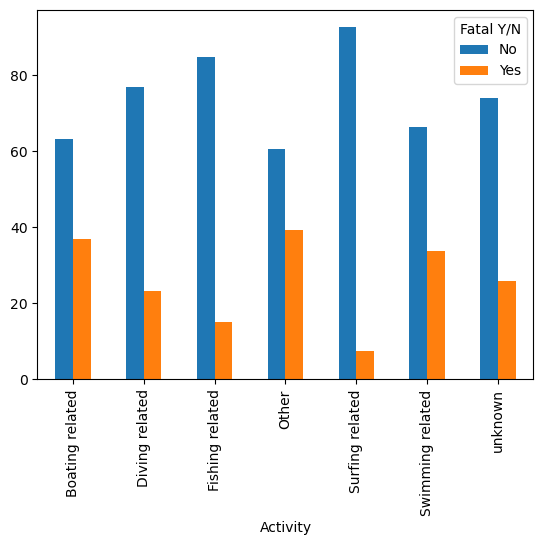

In [48]:
fatal_rate.plot (kind ="bar")

Among the recorded shark attacks swimming, surfing and fishing related activities are the most frequent in the dataset. 
Boating related act has the highest fatal rate, followed by swimming. 

The highest non fatal rate is related to surfing related, followed by fishing and diving. 


- Gender - activity
- gender - fatal 

In [49]:
gender_fatal = df[(df["Sex"] != "Unknown") & (df["Fatal Y/N"] != "Unknown")]
gender_fatal ["Sex"].value_counts()

Sex
M    5237
F     744
Name: count, dtype: int64

In [50]:
df_fatal.columns

Index(['No', 'Yes'], dtype='object', name='Fatal Y/N')

In [51]:
gender_fatal.columns

Index(['Country', 'Activity', 'Location', 'Sex', 'Fatal Y/N', 'Species',
       'Type'],
      dtype='object')

In [52]:
gender_fatal_rate = (pd.crosstab (gender_fatal ["Sex"], gender_fatal ["Fatal Y/N"], normalize = "index")*100).round (2)
gender_fatal_rate

Fatal Y/N,No,Yes
Sex,,
F,83.20,16.80
M,75.94,24.06


<Axes: xlabel='Sex'>

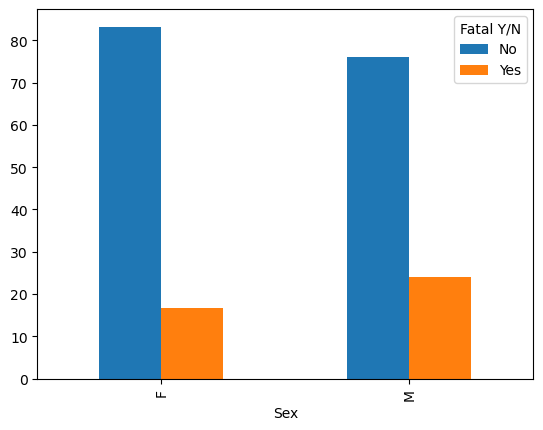

In [53]:
gender_fatal_rate.plot (kind = "bar")

Shark attacks are recorded much more frequently among males than females.
Fatal rates are slightly higher in males than females, and non fatal rates slightly lower than female, biased by gender, as much more males than females in the dataset. 


In [57]:
df_fatal2 ["Activity"].value_counts()

Activity
Swimming related    1766
Surfing related     1652
Fishing related     1272
Other                977
Diving related       702
Boating related      142
Name: count, dtype: int64

In [58]:
sex_activity_rate = (pd.crosstab (df_fatal2["Activity"], gender_fatal ["Sex"], normalize = "index")*100).round (2)
sex_activity_rate

Sex,F,M
Activity,,
Boating related,11.21,88.79
Diving related,14.52,85.48
Fishing related,2.14,97.86
Other,12.53,87.47
Surfing related,8.21,91.79
Swimming related,22.06,77.94


In [ ]:
gender_fatal ["Sex"].value_counts()

In [ ]:
sex_activity_rate.plot (kind = "bar")

# Not meaningful as males registries are significantly higher than females. 

In [60]:
gender_fatal["Sex"].value_counts(normalize=True)*100

Sex
M    87.560609
F    12.439391
Name: proportion, dtype: float64

### VILDAN

In [ ]:
import pandas as pd 
data = pd.read_excel("C:/Users/mocim/OneDrive/Desktop/Lessons/Week 2/Project/raw_data_shark_attacks.xls")

In [ ]:
df = data[["Country", "Activity", "Location", "Sex", "Fatal Y/N", "Species ", "Type"]].copy()

In [ ]:
df['Country'].value_counts()

In [ ]:
df['Country'] = df['Country'].str.strip().str.upper()

In [ ]:
df['Country'] = df['Country'].replace({
    'RED SEA?': 'UNKNOWN',
    'ASIA?': 'UNKNOWN',
    'CEYLON (SRI LANKA)': 'SRI LANKA'
})

In [ ]:
df['Country'].value_counts()

In [ ]:
df['Country'].isna().sum()

In [ ]:
df['Country'] = df['Country'].fillna("UNKNOWN")

In [ ]:
df['Country'].value_counts().tail(20)

In [ ]:
country_fixes = {
    'OCEAN': 'UNKNOWN',
    'INDIAN OCEAN?': 'UNKNOWN',
    'AFRICA': 'UNKNOWN',
    'COAST OF AFRICA': 'UNKNOWN',
    'TASMAN SEA': 'UNKNOWN',
    'ITALY / CROATIA': 'UNKNOWN',
    'EQUATORIAL GUINEA / CAMEROON': 'UNKNOWN',
    'BETWEEN PORTUGAL & INDIA': 'UNKNOWN',
    'BAHREIN': 'BAHRAIN',
    'ROATAN': 'HONDURAS',
    'BRITISH NEW GUINEA': 'PAPUA NEW GUINEA',
    'SAN DOMINGO': 'DOMINICAN REPUBLIC'
}

df['Country'] = df['Country'].replace(country_fixes)

LOCATION

In [ ]:
df['Location'].value_counts()

In [ ]:
df['Location'] = df['Location'].str.strip().str.upper()

In [ ]:
df['Location'] = df['Location'].fillna('UNKNOWN')

In [ ]:
df['Location'].value_counts()

In [ ]:
df['Type'].value_counts()

In [ ]:
df['Type'] = df['Type'].str.strip().str.upper()

In [ ]:
df['Type'] = df['Type'].fillna('UNKNOWN')

In [ ]:
df['Type'].value_counts()

In [ ]:
type_fixes = {
    'BOAT': 'WATERCRAFT',
    '?': 'UNKNOWN',
    'UNCONFIRMED': 'UNKNOWN',
    'UNVERIFIED': 'UNKNOWN',
    'UNDER INVESTIGATION': 'UNKNOWN',
    'QUESTIONABLE': 'UNKNOWN',
    'INVALID': 'UNKNOWN'
}

df['Type'] = df['Type'].replace(type_fixes)
df['Type'].value_counts()

In [ ]:
df

In [ ]:
df.nunique()

In [ ]:
top_countries = df["Country"].value_counts().head(5).index
subset = df[df["Country"].isin(top_countries)]
pd.crosstab(subset["Country"], subset["Fatal Y/N"], normalize="index").round(2) * 100

### KEAGAN

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df['Species'].value_counts()

# check how many unique values exist in Species
# and how often each one appears - reveals how messy the data is - "Diagnose the mess"

In [ ]:
keywords = ['white', 'bull', 'tiger']

# map messy Species strings to clean labels using keyword matching - confirming that searching for "white, bull, tiger" catches the right sharks

for keyword in keywords:
    species_lower = df['Species'].dropna().str.lower()
    matches = species_lower.str.contains(keyword)
    print(f"\n--- '{keyword}' matches ---")
    print(sorted(df['Species'].dropna()[matches].unique()))

In [ ]:
import numpy as np

# map all species variations to clean labels using keyword matching, 
# case=False means upper/lower case doesn't matter, na=False means if the value is empty/NaN just answer false instead of crashing 
# verify the result
# creates a new Species_Clean column rather than overwriting the original

conditions = [
    df['Species'].str.contains('white|pointer', case=False, na=False),
    df['Species'].str.contains('bull', case=False, na=False),
    df['Species'].str.contains('tiger', case=False, na=False),
]
choices = ['Great White', 'Bull Shark', 'Tiger Shark']

df['Species_Clean'] = np.select(conditions, choices, default='Other')

df['Species_Clean'].value_counts()

In [ ]:
df['Fatal Y/N'].value_counts()

# check for y/n and any other values that needs fixing

In [ ]:
df['Fatal Y/N'] = df['Fatal Y/N'].str.strip().str.upper()
df = df[df['Fatal Y/N'].isin(['Y', 'N'])]

# clean the Fatal Y/N column: remove any leading/trailing whitespace then make everything uppercase, keep only the rows where the value is exactly Y or N, drop everything else

In [ ]:
df['Fatal Y/N'].value_counts()

# confirming only Y and N remain after cleaning

In [ ]:
# calculate what % of attacks were fatal per species
# to test hypothesis: Are Great White attacks more likely to be fatal?

fatality_rate =  df.groupby('Species_Clean')['Fatal Y/N'].apply(
    lambda x: (x == 'Y').sum() / len(x) * 100
).round(1)

print(fatality_rate)

In [ ]:
# Conclusions: Species alone isn't a strong predictor of fatality - the top 3 named sharks sit within 20 to 24 percent
# Great Whites have a more famous/worst reputation, but Tiger Sharks are marginally more likely to be fatal
# Similarity  across species suggests other factors (location, activity, access to medical) care might matter more than species
# The "Other" category at 23.1% is suspiciously high and contains mixed or unknown species, likely skewing things